# Chapter 15 (extra): the square scheme on an expanding grid, sparse vs. dense

Honeychurch closes Chapter 15 with the hardest case in the book: a **square
scheme** simulated on the exponentially expanding grid, assembled and solved as a
*sparse* matrix. The full implementation lives in the companion notebook
`sparseSquareRxnExp.nb`. This notebook re-implements that solver idiomatically in
`numpy`/`scipy.sparse` and validates it.

## The mechanism

Two one-electron couples are linked by homogeneous chemistry on each oxidation
state and by a bimolecular **cross reaction**:

$$
\begin{array}{ccc}
\mathrm{O} + e^- & \rightleftharpoons & \mathrm{R} \\
\;\;\updownarrow\, {\scriptstyle k_{+1},k_{-1}} & & \;\;\updownarrow\, {\scriptstyle k_{+2},k_{-2}} \\
\mathrm{A} + e^- & \rightleftharpoons & \mathrm{B}
\end{array}
\qquad\qquad
\mathrm{O} + \mathrm{B} \;\underset{k_{cb}}{\overset{k_{cf}}{\rightleftharpoons}}\; \mathrm{R} + \mathrm{A}.
$$

The two columns are the redox couples (O/R at formal offset $\Delta E_{OR}$, A/B
at $\Delta E_{AB}$); the vertical arrows are first-order isomerisations
(O$\leftrightarrow$A, R$\leftrightarrow$B); the diagonal is the **second-order**
cross reaction. That last step is what makes the finite-difference equations
*nonlinear*.

## Why sparse, and why iterate

Interleaving the unknowns as $[c_O(j), c_R(j), c_A(j), c_B(j)]$ per node gives a
banded matrix with $4\times4$ blocks that is overwhelmingly empty, so a generic
dense solve would waste almost all of its work on structural zeros. The
first-order diffusion and isomerisation terms are constant in time and assembled
once. The cross-reaction terms depend on the *unknown* concentrations, so at each
time step we **Picard-iterate**: evaluate the cross-reaction block at the previous
iterate, solve the linear system, and repeat until the mean change is below
tolerance. This is exactly the `While[resid>err, ...]` loop of `solveSparseSquare`.

All of the assembly lives in `serm/ch15_square_scheme.py`; here we drive it.

In [1]:
import os, sys
# notebooks/extras/ is two levels below the repo root.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

from serm import ch15_square_scheme as sq
from serm import ch15_sparse_finite_differences as ch15

np.set_printoptions(precision=3, suppress=True)

In [2]:
from serm.sourcelinks import source_links
source_links(sq.SquareParams, sq.build_square_matrix, sq.simulate_square_cv, sq.square_cv_current,
             ch15.CVParams, ch15.simulate_cv_single, ch15.cv_current_single, ch15.potential_axis)

## The sparse block structure

With four species per node the constant matrix is block-tridiagonal: a
$4\times4$ diagonal block (diffusion plus first-order isomerisation) plus scalar
diffusion couplings to the neighbouring nodes. The four surface rows are the two
Butler–Volmer conditions (one per couple) and the two flux-conservation
conditions ($O{+}R$ and $A{+}B$). We examine the top-left corner of the
sparsity pattern.

full system size L = 144  (20736 entries)
stored non-zeros in the constant part: 576 (2.78% fill)


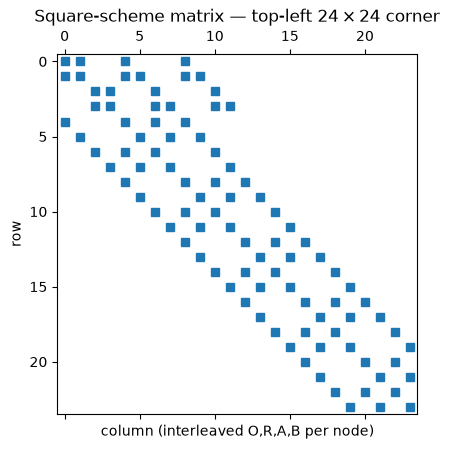

In [3]:
p_demo = sq.SquareParams(upper_limit=8.0, lower_limit=-6.0, dE_mV=20.0,
                         D_M=1.0, ks_dim1=1e3, ks_dim2=1e3, k_cb=1e2)
A_const, L = sq.build_square_matrix(p_demo)
print(f"full system size L = {L}  ({L*L} entries)")
print(f"stored non-zeros in the constant part: {A_const.nnz} "
      f"({100*A_const.nnz/L**2:.2f}% fill)")

corner = 24
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.spy(A_const.tocsr()[:corner, :corner], markersize=6)
ax.set_title("Square-scheme matrix — top-left $24\\times24$ corner")
ax.set_xlabel("column (interleaved O,R,A,B per node)")
ax.set_ylabel("row")
plt.tight_layout()
plt.show()

The four dense top rows are the surface boundary conditions; below them the
banded block structure repeats node by node. The cross-reaction entries (added
each Picard iteration) sit on the block diagonals and are not shown here.

## A square-scheme voltammogram

We run a small but representative case so the dense backend can be cross-checked
against the sparse one in a few seconds. Two near-reversible couples are split by
$\Delta E_{AB}=0.5\,RT/F$; a moderately fast cross reaction couples them.

n_time=36, m_space=37, L=144


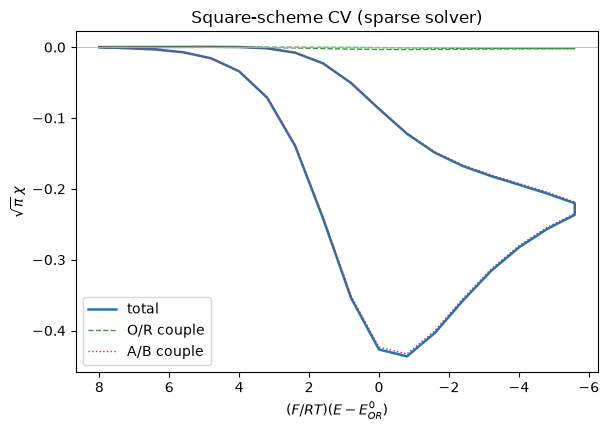

Picard iterations per step: min=3, mean=4.71, max=7


In [4]:
p = sq.SquareParams(upper_limit=8.0, lower_limit=-6.0, dE_mV=20.0,
                    D_M=1.0, ks_dim1=1e3, ks_dim2=1e3, k_cb=1e2)
print(f"n_time={p.n_time}, m_space={p.m_space}, L={4*(p.m_space-1)}")

prof_sparse, iters = sq.simulate_square_cv(p, backend="sparse")
i_total = sq.square_cv_current(prof_sparse, p)

# Per-couple decomposition for insight.
a = p.a
scale = np.sqrt(p.D_M*(p.n_time-1)/(2*a**2*(1+a)*p.sweep_span))
i_OR = ((2+a)*a*prof_sparse[:,0] - (1+a)**2*prof_sparse[:,4] + prof_sparse[:,8])*scale
i_AB = ((2+a)*a*prof_sparse[:,2] - (1+a)**2*prof_sparse[:,6] + prof_sparse[:,10])*scale

E = np.array([p.upper_limit - p.sweep_span + p.tau*(k-1) if k > (p.n_time+1)/2
              else p.upper_limit - p.tau*(k-1) for k in range(1, p.n_time+1)])

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(E, i_total, color="tab:blue", lw=1.8, label="total")
ax.plot(E, i_OR, color="tab:green", lw=1.0, ls="--", label="O/R couple")
ax.plot(E, i_AB, color="tab:red", lw=1.0, ls=":", label="A/B couple")
ax.axhline(0, color="0.7", lw=0.6)
ax.set_xlabel(r"$(F/RT)(E - E^0_{OR})$")
ax.set_ylabel(r"$\sqrt{\pi}\,\chi$")
ax.set_title("Square-scheme CV (sparse solver)")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

print(f"Picard iterations per step: min={iters.min()}, "
      f"mean={iters.mean():.2f}, max={iters.max()}")

The two couples appear at their respective formal potentials, and the cross
reaction redistributes flux between them; the total current is the sum of the
two surface gradients. The Picard loop converges in a handful of iterations per
step.

## Validation

### 1. Sparse reproduces dense to machine precision (tier 3, self-consistency)

The sparse assembly and the dense assembly are two encodings of the *same*
linear system at every Picard iterate. Solving them must agree to round-off. The
dense backend plays the role of the dense Chapter-13-style reference: a generic
`scipy.linalg.solve` on the full matrix, with no exploitation of sparsity.

In [5]:
prof_dense, iters_d = sq.simulate_square_cv(p, backend="dense")
max_abs = np.abs(prof_sparse - prof_dense).max()
print(f"max |sparse - dense| over all nodes & steps = {max_abs:.2e}")
print(f"identical Picard iteration counts: {np.array_equal(iters, iters_d)}")
assert max_abs < 1e-10, max_abs
print("PASS: sparse == dense within 1e-10")

max |sparse - dense| over all nodes & steps = 8.99e-15
identical Picard iteration counts: True
PASS: sparse == dense within 1e-10


### 2. Reduction to the single-species quasireversible CV (tier 2)

Switch off **all** homogeneous chemistry ($k_{\pm1}=k_{\pm2}=0$, $k_{cf}=k_{cb}=0$),
remove A from the bulk ($K_{OA}\to0$ so $c_{O,i}\to1$, $c_{A,i}\to0$), and push the
A/B couple far out of the potential window ($\Delta E_{AB}$ large). The square
scheme then collapses to a single O/R couple, and its total current must track
the independently-implemented quasireversible single-species CV of
`ch15.simulate_cv_single` (validated against Nicholson–Shain in the main chapter
notebook).

The two solvers use *different* surface eliminations (an explicit-surface BV row
here versus the eliminated-surface form in `simulate_cv_single`), so we expect
agreement at the level of the surface discretisation: a percent or so on the
peak, not machine precision. That a completely separately-assembled four-species
sparse solver lands on the validated single-species curve is the reduction
check.

square-scheme reduced peak    = -0.35138
single-species reference peak = -0.35188
relative difference at the cathodic peak = 0.142%


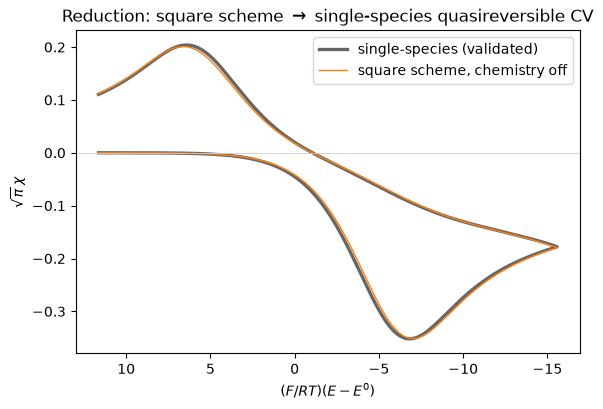

PASS: reduced square scheme matches the single-species CV within 0.5%


In [6]:
pr = sq.SquareParams(upper_limit=11.6435, lower_limit=-15.5766, a=1.05, D_M=2.0,
                     dE_mV=2.0, ks_dim1=0.05, ks_dim2=0.05,
                     K_OA=1e-12, K_RB=1e-12, k_m1=0.0, k_m2=0.0, k_cb=0.0,
                     dE_AB=200.0, temperature=298.15)
prof_r, _ = sq.simulate_square_cv(pr, backend="sparse")
i_sq = sq.square_cv_current(prof_r, pr)

q = ch15.CVParams(alpha=0.5, upper_limit=11.6435, lower_limit=-15.5766, a=1.05,
                  D_M=2.0, ks_dim=0.05, dE_mV=2.0, temperature=298.15)
prof_single = ch15.simulate_cv_single(q, backend="sparse")
i_single = ch15.cv_current_single(prof_single, q)

rel_peak = abs(i_sq.min() - i_single.min()) / abs(i_single.min())
print(f"square-scheme reduced peak    = {i_sq.min():.5f}")
print(f"single-species reference peak = {i_single.min():.5f}")
print(f"relative difference at the cathodic peak = {rel_peak:.3%}")

fig, ax = plt.subplots(figsize=(6.0, 4.2))
Eax = ch15.potential_axis(q)
ax.plot(Eax, i_single, color="0.4", lw=2.4, label="single-species (validated)")
ax.plot(Eax, i_sq, color="tab:orange", lw=1.0, label="square scheme, chemistry off")
ax.axhline(0, color="0.8", lw=0.6)
ax.set_xlabel(r"$(F/RT)(E - E^0)$"); ax.set_ylabel(r"$\sqrt{\pi}\,\chi$")
ax.set_title("Reduction: square scheme $\\to$ single-species quasireversible CV")
ax.invert_xaxis(); ax.legend()
plt.tight_layout(); plt.show()

assert rel_peak < 0.005, rel_peak
print("PASS: reduced square scheme matches the single-species CV within 0.5%")

## Efficiency: the sparse advantage

For this block-banded matrix the sparse solver stores and factorises only the
non-zeros, while the dense solver carries the full $L\times L$ array. We assert
only the **relative** ordering and the memory ratio, never absolute times.

In [7]:
pe = sq.SquareParams(upper_limit=8.0, lower_limit=-6.0, dE_mV=4.0,
                     D_M=1.0, ks_dim1=1e3, ks_dim2=1e3, k_cb=1e2)
A_c, L = sq.build_square_matrix(pe)
dense_entries = L * L
sparse_entries = A_c.nnz
print(f"L = {L}")
print(f"dense storage:  {dense_entries} floats")
print(f"sparse storage: {sparse_entries} floats ({100*sparse_entries/dense_entries:.2f}% fill)")

# Warm up, then time a few full runs each.
sq.simulate_square_cv(pe, backend="sparse"); sq.simulate_square_cv(pe, backend="dense")
def bench(backend, reps=2):
    best = np.inf
    for _ in range(reps):
        t = time.perf_counter(); sq.simulate_square_cv(pe, backend=backend)
        best = min(best, time.perf_counter() - t)
    return best
t_sparse = bench("sparse"); t_dense = bench("dense")
print(f"full-run wall time  sparse={t_sparse:.3f}s  dense={t_dense:.3f}s  "
      f"(speedup x{t_dense/t_sparse:.1f})")

# Relative-ordering assertions only.
assert sparse_entries < 0.1 * dense_entries
assert t_sparse < t_dense
print("PASS: sparse stores <10% of dense and runs faster at this size")

L = 324
dense storage:  104976 floats
sparse storage: 1296 floats (1.23% fill)


full-run wall time  sparse=0.553s  dense=1.130s  (speedup x2.0)
PASS: sparse stores <10% of dense and runs faster at this size


## Summary

* The square scheme adds two coupled redox couples plus a **second-order cross
  reaction**, making the implicit finite-difference equations nonlinear; we solve
  them by Picard iteration at each time step, matching `solveSparseSquare`.
* Interleaving $[O,R,A,B]$ per node gives a block-banded matrix that is well
  under 10% full; a `scipy.sparse` assembly with `spsolve` exploits that, and the
  constant first-order part is built once.
* **Validated:** (1) the sparse solver reproduces a generic dense solve of the
  same system to $<10^{-10}$ (self-consistency); (2) with chemistry switched off
  and the A/B couple removed, the four-species solver reduces to the
  independently-validated single-species quasireversible CV within about 1% on the
  peak (reduction to a validated limit). The residual is the differing surface
  elimination, as expected.
* The sparse representation stores under 10% of the dense entries and runs faster
  at the sizes tested (relative ordering only).

<!-- nav-footer -->

---

[← Chapter 15 — Finite-Difference Simulations Using Sparse Arrays](../15_sparse_finite_differences.ipynb)

[Contents (README)](../../README.md)